In [ ]:
pip install opencv-python numpy


In [ ]:
pip install stitching

✅ Displaying Left Image


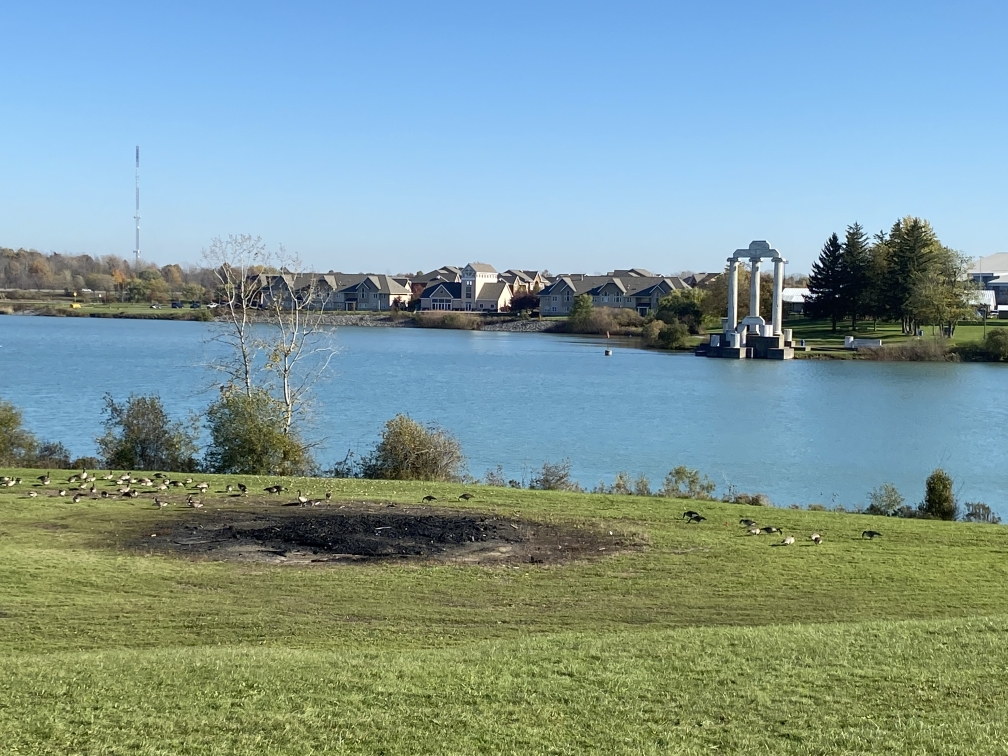

✅ Displaying Right Image


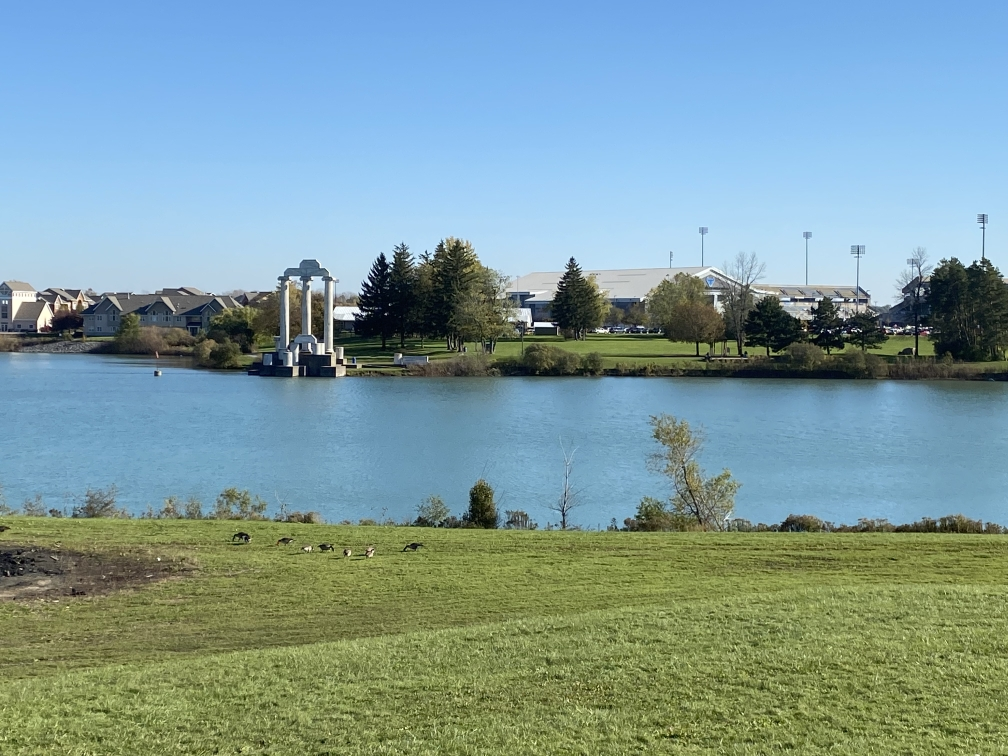

🔍 Found 954 good matches.
✅ Image stitching successful! Showing result below:


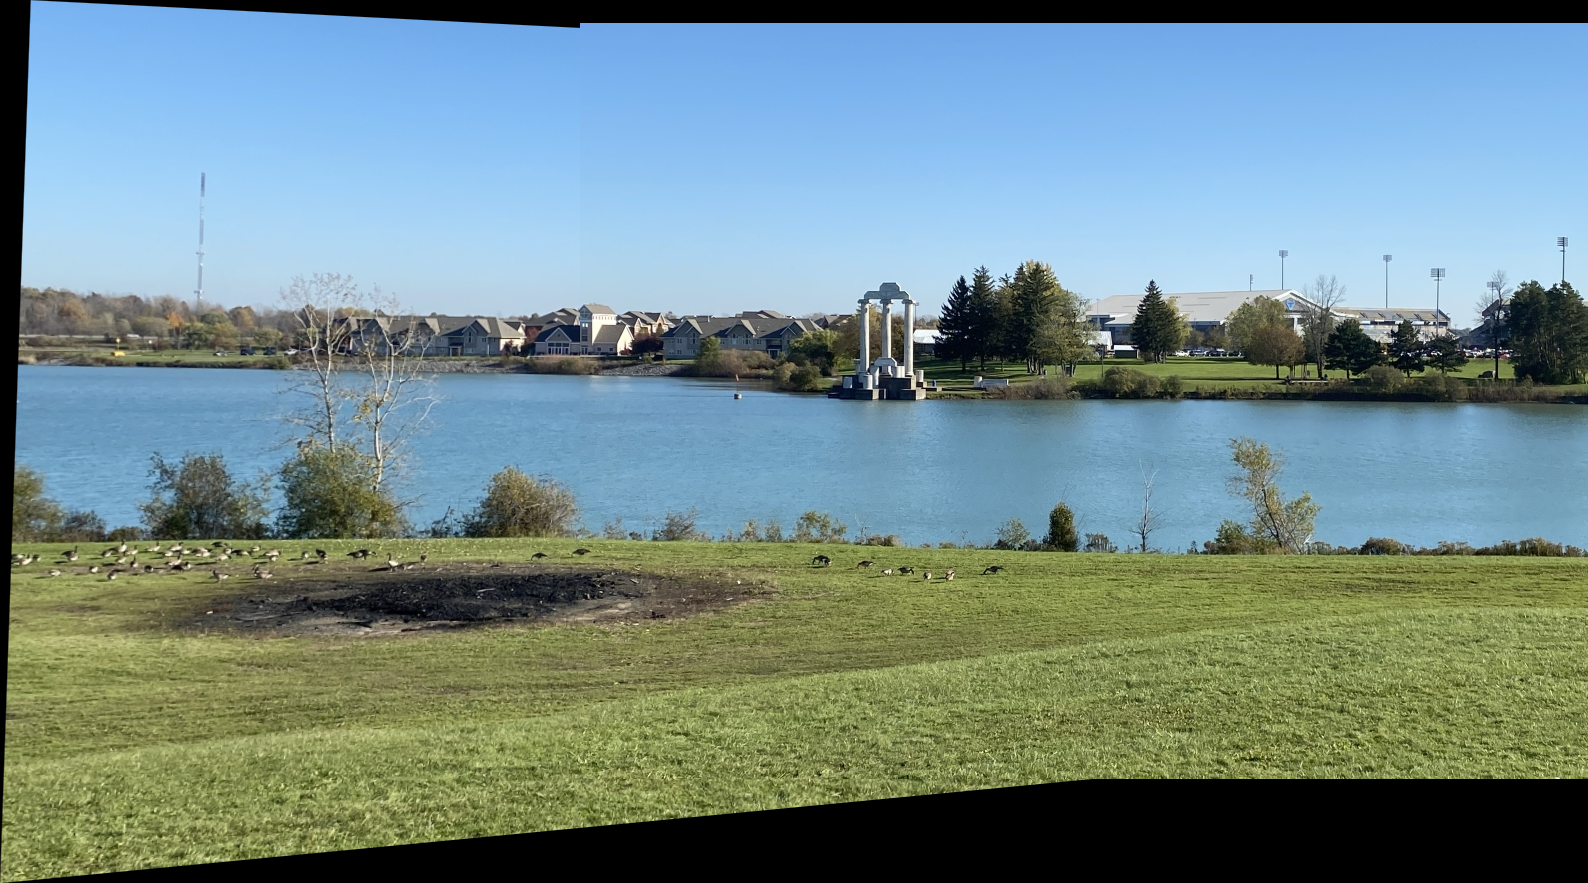

In [ ]:
import cv2
import numpy as np
import random
from google.colab.patches import cv2_imshow  # For image display in Google Colab

def solution(left_img, right_img):
    key_points1, descriptor1, key_points2, descriptor2 = get_keypoint(left_img, right_img)
    good_matches = match_keypoint(key_points1, key_points2, descriptor1, descriptor2)

    if len(good_matches) < 4:
        print(f"❌ Not enough good matches found! ({len(good_matches)})")
        return None

    final_H = ransac(good_matches)

    if final_H is None:
        print("❌ RANSAC failed to compute a valid homography.")
        return None

    result_img = stitch_images(left_img, right_img, final_H)
    return result_img

def get_keypoint(left_img, right_img):
    sift = cv2.SIFT_create()
    key_points1, descriptor1 = sift.detectAndCompute(left_img, None)
    key_points2, descriptor2 = sift.detectAndCompute(right_img, None)
    return key_points1, descriptor1, key_points2, descriptor2

def match_keypoint(key_points1, key_points2, descriptor1, descriptor2):
    flann = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))
    matches = flann.knnMatch(descriptor1, descriptor2, k=2)

    good_matches = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            left_pt = key_points1[m.queryIdx].pt
            right_pt = key_points2[m.trainIdx].pt
            good_matches.append([left_pt[0], left_pt[1], right_pt[0], right_pt[1]])

    print(f"🔍 Found {len(good_matches)} good matches.")
    return good_matches

def homography(points):
    A = []
    for pt in points:
        x, y = pt[0], pt[1]
        X, Y = pt[2], pt[3]
        A.append([x, y, 1, 0, 0, 0, -X * x, -X * y, -X])
        A.append([0, 0, 0, x, y, 1, -Y * x, -Y * y, -Y])

    A = np.array(A)
    _, _, vh = np.linalg.svd(A)
    H = vh[-1, :].reshape(3, 3)
    return H / H[2, 2]

def ransac(good_pts, iterations=1000, threshold=5):
    if len(good_pts) < 4:
        return None  # Not enough matches for homography

    best_inliers = []
    best_H = None

    for _ in range(iterations):
        sample_pts = random.sample(good_pts, 4)
        H = homography(sample_pts)
        inliers = []

        for pt in good_pts:
            p = np.array([pt[0], pt[1], 1]).reshape(3, 1)
            p_1 = np.array([pt[2], pt[3], 1]).reshape(3, 1)
            Hp = np.dot(H, p)
            Hp /= Hp[2]

            if np.linalg.norm(p_1 - Hp) < threshold:
                inliers.append(pt)

        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_H = H

    return best_H

def stitch_images(left_img, right_img, H):
    rows1, cols1 = right_img.shape[:2]
    rows2, cols2 = left_img.shape[:2]

    points1 = np.float32([[0, 0], [0, rows1], [cols1, rows1], [cols1, 0]]).reshape(-1, 1, 2)
    points2 = np.float32([[0, 0], [0, rows2], [cols2, rows2], [cols2, 0]]).reshape(-1, 1, 2)
    points2_transformed = cv2.perspectiveTransform(points2, H)

    points_combined = np.concatenate((points1, points2_transformed), axis=0)
    [x_min, y_min] = np.int32(points_combined.min(axis=0).ravel() - 0.5)
    [x_max, y_max] = np.int32(points_combined.max(axis=0).ravel() + 0.5)

    translation_matrix = np.array([[1, 0, -x_min], [0, 1, -y_min], [0, 0, 1]], dtype=np.float32)
    warped_img = cv2.warpPerspective(left_img, translation_matrix.dot(H), (x_max - x_min, y_max - y_min))

    mask = np.ones_like(right_img) * 255
    right_warped = cv2.warpPerspective(right_img, translation_matrix, (x_max - x_min, y_max - y_min))
    mask_warped = cv2.warpPerspective(mask, translation_matrix, (x_max - x_min, y_max - y_min))

    stitched = np.where(mask_warped == 255, right_warped, warped_img)
    return crop_black_borders(stitched)

def crop_black_borders(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)
    x, y, w, h = cv2.boundingRect(thresh)
    return img[y:y+h, x:x+w]

if __name__ == "__main__":
    left_img = cv2.imread("/content/left.jpg")
    right_img = cv2.imread("/content/right.jpg")

    if left_img is None or right_img is None:
        print("❌ Error: Could not load images. Check file paths.")
    else:
        print("✅ Displaying Left Image")
        cv2_imshow(left_img)

        print("✅ Displaying Right Image")
        cv2_imshow(right_img)

        result_img = solution(left_img, right_img)

        if result_img is not None:
            cv2.imwrite("stitched_output.jpg", result_img)
            print("✅ Image stitching successful! Showing result below:")
            cv2_imshow(result_img)
        else:
            print("❌ Image stitching failed.")
